## Studying convergence with time

We are going to represent the resulted curves of running the script "simulate_spacers" in ten different times.

The final time is 200000 (when we know for sure it will reach the stationary state), and the rest of times were calculated in a logarithmic scale:

$log(200000)/10 = unit$

$unit * 1 = x; 10^x = t1$

$unit * 2 = x; 10^x = t2$

...


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
# The data is in a text file with spaces separating columns
def load_file(file_path):
    # Load the data, skipping the first 5 lines
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    data = data.iloc[:, :-1] # Remove the last column "(means)"
    return data

# Load both files
file1 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_3'  
file2 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_12' 
file3 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_39'
file4 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_132'
file5 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_447'
file6 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_1516'
file7 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_5137'
file8 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_17411'
file9 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_59010'
file10 = '/Users/jimenamartinreina/Documents/UNI/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/141124/OutputFile_time_200000'


data1 = load_file(file1)
data2 = load_file(file2)
data3 = load_file(file3)
data4 = load_file(file4)
data5 = load_file(file5)
data6 = load_file(file6)
data7 = load_file(file7)
data8 = load_file(file8)
data9 = load_file(file9)
data10 = load_file(file10)

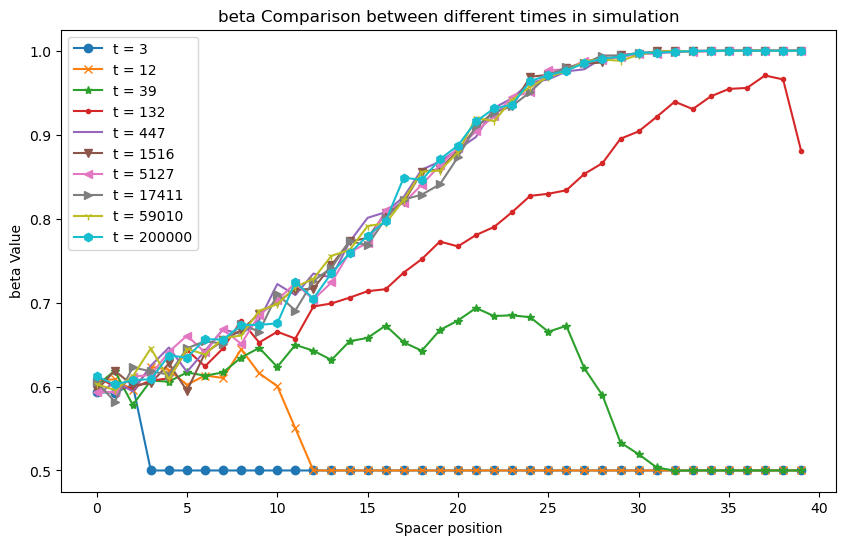

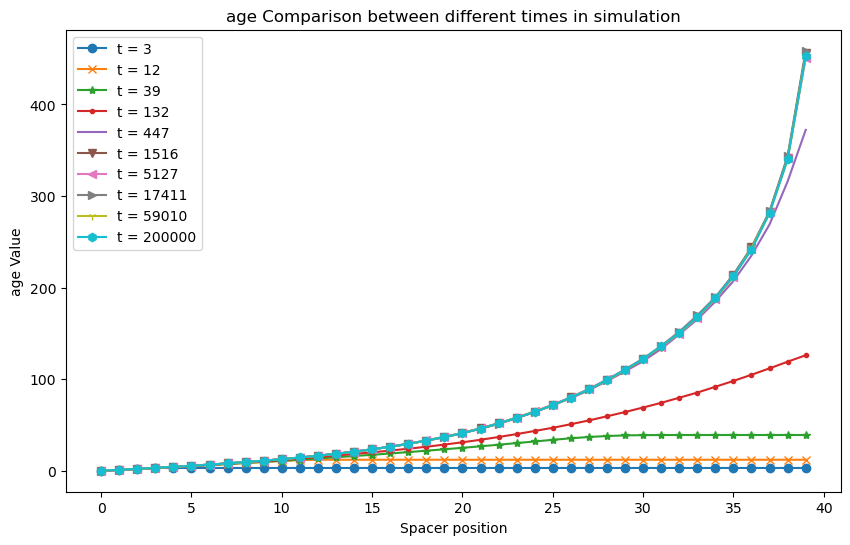

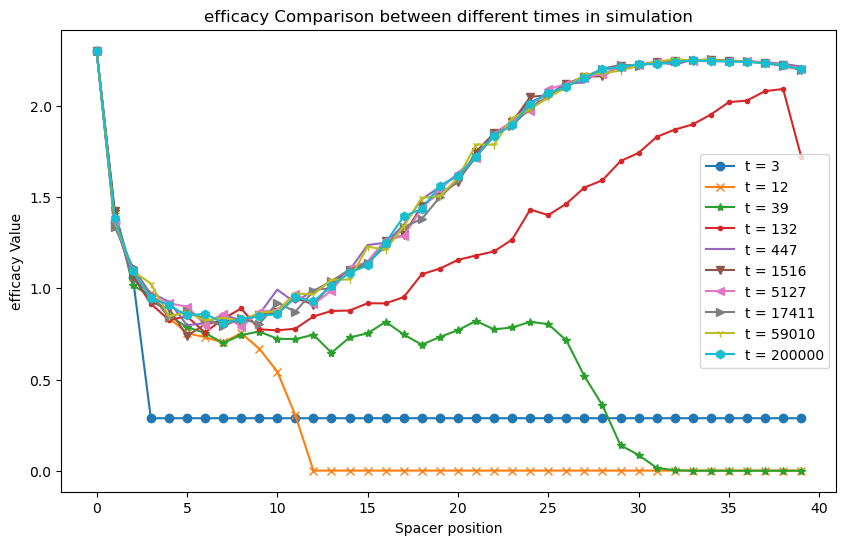

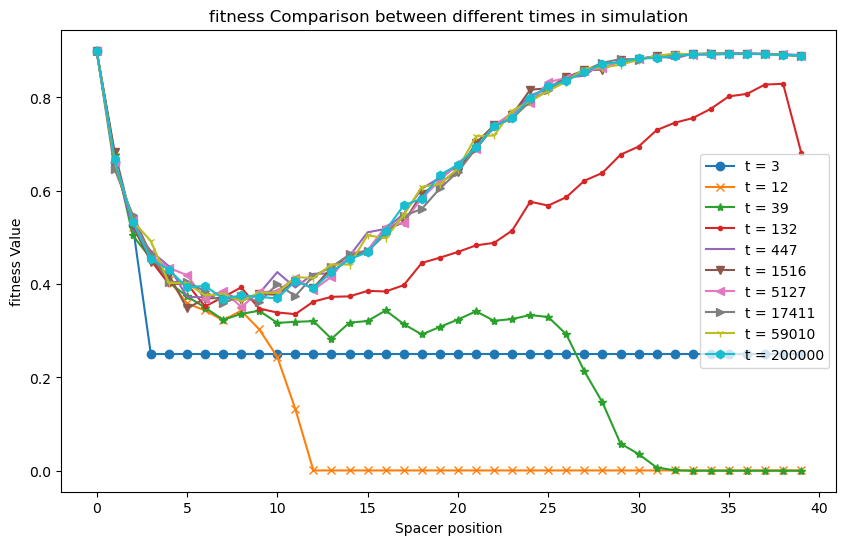

In [3]:
# Get the list of columns to plot ( both files have the same columns)
columns = data1.columns

# Loop over each column to plot them
for column in columns:
    plt.figure(figsize=(10, 6))

    # Plot the data for the current column from both files
    plt.plot(data1.index, data1[column], label=f't = 3', marker='o')
    plt.plot(data2.index, data2[column], label=f't = 12', marker='x')
    plt.plot(data3.index, data3[column], label=f't = 39', marker='*')
    plt.plot(data4.index, data4[column], label=f't = 132', marker='.')
    plt.plot(data5.index, data5[column], label=f't = 447', marker=',')
    plt.plot(data6.index, data6[column], label=f't = 1516', marker='v')
    plt.plot(data7.index, data7[column], label=f't = 5127', marker='<')
    plt.plot(data8.index, data8[column], label=f't = 17411', marker='>')
    plt.plot(data9.index, data9[column], label=f't = 59010', marker='1')
    plt.plot(data10.index, data10[column], label=f't = 200000', marker='h')

    # Adding title and labels
    plt.title(f'{column} Comparison between different times in simulation')
    plt.xlabel('Spacer position')
    plt.ylabel(f'{column} Value')
    plt.legend()

    # Show the plot for the current column
    plt.show()


It seems that from t = 447 on, the beta, age, efficacy and fitness values are almost the same than the ones obtained with t = 200000.

The betas converge to 0.9999 at the same time; the same occurs to efficacy and fitness values, the latter converging to almost 1.

The only differences are:
- The exact points of beta, efficacy and fitness are not the same until position 30, but they don't differ much. This variationo does not depend on the time of simulation. For instance, if we compare curves t=200k vs 59k and then 200k vs 447, the variability is really similar. This means the variability we observe is due to the number of replicates. The way to make results more reproducible is to increase the number of replicates, regardless of the time of simulation.
- The final spacer's age for t = 447 doesn't reach the final value of the other simulation, close to 450 generations. For t = 447, the final age value is 372. This happens because time equal to 447 is lower than the maximum age of equilibrium, so it does not have time to reach the equilibrium regarding age values.

To sum up, it's surprising that the behaviour of the system when the time is 200000 can be almost the same with time equal to 447. We have to bear in mind that this simulation was done for parameters:
- alpha = 0.1
- gamma = 0
- pEndemic = 0.2
- number of spacers = 40
- replicates = 1000

The results we obtain inform us about the way the system works and give us a strategy to fix the time simulation based on the age of the last spacer.

We can start fixing the time to a value much higher than the age of the last spacer. For instance, tmax = 5000, which is 10 times the age of the oldest spacer (in this combination of parameters).

Then, we run the simulations with this time (and any parameters) and erify the last spacer's age. 
If it is at least 5 times lower than the time of simulation, we take the simulatioin for valid.
On the contrary, we increase the simulation time and repeat.